In [5]:
import numpy as np 

import matplotlib.pyplot as plt
from scipy.integrate import quad
import csv

# sparse simulation
import scipy.sparse as sp
import scipy.sparse.linalg as spla

<>:18: SyntaxWarning: invalid escape sequence '\z'
<>:18: SyntaxWarning: invalid escape sequence '\z'
/var/folders/d9/ht8ll8_j71jdf3whd48h7gww0000gn/T/ipykernel_70590/1630415748.py:18: SyntaxWarning: invalid escape sequence '\z'
  """


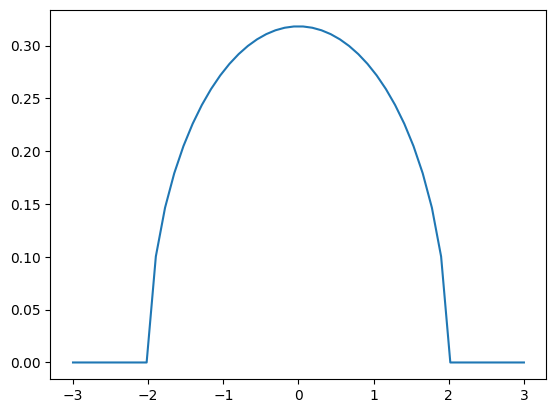

In [19]:
def q_minus(k, r):
    """ single-mode q^(r,-)(k) """
    return -2.0 * np.sin(r * k)
    
def theta(x):
    """ Heaviside with θ(0) = 1/2 """
    if x > 0:
        return 1.0
    if x < 0:
        return 0.0
    return 0.5

def n_zeta(k,zeta):
    v_k = 2*np.sin(k)
    return (1/(4*np.pi))*theta(zeta-v_k) 

def hyd_charge(r, zeta):
    """
    ⟨ q^{(r,sign)} ⟩_{n_\zeta}
      = ∫ dk q^{(r,sign)}(k) n_\zeta(k)
    """
    qfun = q_minus 

    def f(k):
        return qfun(k, r) * n_zeta(k, zeta)

    val, _ = quad(f, -np.pi, np.pi, limit=500)
    
    return val

Z= np.linspace(-3,3)
q = np.array([hyd_charge(1,z) for z in Z])
plt.plot(Z,q)